# **Homework 10 - Adversarial Attack**

Slides: https://reurl.cc/v5kXkk

Video(En): https://youtu.be/313TZsUDQ48

Video(Zh): https://youtu.be/xWHpPEvkDiE

TA: ntu-ml-2021spring-ta@googlegroups.com

## Enviroment & Download

We make use of [pytorchcv](https://pypi.org/project/pytorchcv/) to obtain CIFAR-10 pretrained model, so we need to set up the enviroment first. We also need to download the data (200 images) which we want to attack.

In [1]:
# 安裝 pytorchcv，用來取得 CIFAR-10 pretrained models
!pip install pytorchcv

# 下載 200 張測試圖片
!gdown --id 1fHi1ko7wr80wXkXpqpqpOxuYH1mClXoX -O data.zip

# 解壓縮並刪除 zip 檔
!unzip ./data.zip
!rm ./data.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.2/134.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.2/585.2 kB 13.3 MB/s eta 0:00:00
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1fHi1ko7wr80wXkXpqpqpOxuYH1mClXoX
To: /content/data.zip
100% 490k/490k [00:00<00:00, 6.09MB/s]
Archive:  ./data.zip
   creating: data/
   creating: data/deer/
 extracting: data/deer/deer13.png    
 extracting: data/deer/deer6.png     
 extracting: data/deer/deer11.png    
 extracting: data/deer/deer2.png     
 extracting: data/deer/deer10.png    
 extracting: data/deer/deer16.png    
 extracting: data/deer/deer9.png     
 extracting: data/deer/deer20.png    
 extracting: data/deer/deer15.png    
 extracting: data/deer/deer19.png    
 extracting: data/deer/dee

## Global Settings

* $\epsilon$ 固定為 8。但資料前處理會先用 ToTensor()（0-255 → 0-1）再用 Normalize()（減 mean 除 std），所以攻擊時 $\epsilon$ 必須換算成 $\frac{8}{255 \times std}$。

* 詳細推導：
    * 原始像素 $p$，對抗樣本像素 $a$，約束為 $|p - a| \leq 8$
    * 經過 ToTensor 和 Normalize 後，約束變為 $\frac{1}{255 \times std}|p - a| \leq \frac{8}{255 \times std}$
    * 因此在正規化空間中，$\epsilon = \frac{8}{255 \times std}$

In [2]:
import torch
import torch.nn as nn

# 選擇運算裝置：有 GPU 用 GPU，否則用 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置：{device}')

batch_size = 8

# CIFAR-10 資料集的 channel-wise mean 和 std（R, G, B 三個 channel）
cifar_10_mean = (0.491, 0.482, 0.447)
cifar_10_std  = (0.202, 0.199, 0.201)

# 將 mean 和 std 轉成 (3, 1, 1) 的 tensor，方便後續 broadcast 運算
mean = torch.tensor(cifar_10_mean).to(device).view(3, 1, 1)
std  = torch.tensor(cifar_10_std).to(device).view(3, 1, 1)

# 在正規化空間中的 epsilon（攻擊允許的最大擾動量）
epsilon = 8/255/std

# I-FGSM 的每步步長 alpha：比 epsilon 小，讓攻擊更精細
# 使用 2/255/std，搭配 num_iter=20，總步長上限遠超 epsilon，但會被 clip 限制在 epsilon 內
alpha = 2/255/std

# 存放原始（benign）圖片的資料夾路徑
root = './data'

使用裝置：cuda


## Data

從資料夾讀取圖片，建立 Dataset 和 DataLoader。每張圖片的相對路徑（含類別）會被保存，用來輸出對抗樣本時維持相同的檔案結構。

In [3]:
import os
import glob
import shutil
import numpy as np
from PIL import Image
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader

# 前處理：PIL Image → Tensor（0-1）→ 正規化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_10_mean, cifar_10_std)
])

class AdvDataset(Dataset):
    """讀取對抗攻擊用的圖片資料集"""
    def __init__(self, data_dir, transform):
        self.images = []   # 圖片路徑列表
        self.labels = []   # 對應標籤（class index）
        self.names  = []   # 相對路徑（用來輸出時維持目錄結構）
        '''
        data_dir 結構：
        data_dir
        ├── airplane/
        │   ├── airplane1.png
        │   ├── ...
        │   └── airplane20.png
        ├── automobile/
        ...（共 10 類）
        '''
        for i, class_dir in enumerate(sorted(glob.glob(f'{data_dir}/*'))):
            images = sorted(glob.glob(f'{class_dir}/*'))
            self.images += images
            self.labels += ([i] * len(images))
            self.names  += [os.path.relpath(img, data_dir) for img in images]
        self.transform = transform

    def __getitem__(self, idx):
        # 開啟圖片並套用前處理
        image = self.transform(Image.open(self.images[idx]))
        label = self.labels[idx]
        return image, label

    def __getname__(self):
        return self.names

    def __len__(self):
        return len(self.images)

adv_set   = AdvDataset(root, transform=transform)
adv_names = adv_set.__getname__()
adv_loader = DataLoader(adv_set, batch_size=batch_size, shuffle=False)

print(f'資料集圖片總數 = {adv_set.__len__()}')

資料集圖片總數 = 200


## Utils — 評估 Benign 圖片準確率

In [4]:
def epoch_benign(model, loader, loss_fn):
    """在未加擾動的原始圖片上評估模型準確率"""
    model.eval()
    total_acc, total_loss = 0.0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        yp = model(x)
        loss = loss_fn(yp, y)
        total_acc  += (yp.argmax(dim=1) == y).sum().item()
        total_loss += loss.item() * x.shape[0]
    return total_acc / len(loader.dataset), total_loss / len(loader.dataset)

## Utils — 攻擊演算法

### FGSM（Fast Gradient Sign Method）
$$x' = x + \epsilon \cdot \text{sign}(\nabla_x L(x, y; \theta))$$

概念：對 Loss Function 做一次梯度上升，朝讓模型最困惑的方向擾動圖片。

### I-FGSM（Iterative FGSM）
$$x'_0 = x$$
$$x'_{n+1} = \text{Clip}^\epsilon_x\left(x'_n + \alpha \cdot \text{sign}(\nabla_x L(x, y; \theta))\right)$$

概念：以小步長 $\alpha$ 重複做 FGSM，並在每步後 clip 回以 $x$ 為中心、半徑 $\epsilon$ 的 L-inf ball。

In [5]:
def fgsm(model, x, y, loss_fn, epsilon=epsilon):
    """FGSM：單步梯度上升攻擊"""
    x_adv = x.detach().clone()  # 從 benign 圖片出發，detach 避免影響原本的 graph
    x_adv.requires_grad = True  # 要對 x_adv 求梯度

    loss = loss_fn(model(x_adv), y)  # 計算 Cross Entropy Loss
    loss.backward()                  # 反向傳播，計算 ∂L/∂x_adv

    # 梯度上升：朝增大 Loss 的方向更新 x_adv（讓模型預測錯誤）
    x_adv = x_adv + epsilon * x_adv.grad.detach().sign()
    return x_adv


def ifgsm(model, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=20):
    """I-FGSM：多步小步長迭代攻擊，每步後 clip 確保在 epsilon-ball 內"""
    x_adv = x.detach().clone()  # 初始化為 benign 圖片

    for _ in range(num_iter):
        x_adv.requires_grad_(True)          # 每步都要重新設定 requires_grad

        loss = loss_fn(model(x_adv), y)     # 計算 Loss
        loss.backward()                      # 反向傳播

        # 以小步長 alpha 做一步 FGSM 更新
        x_adv = x_adv + alpha * x_adv.grad.detach().sign()

        # Clip：確保對抗樣本與原圖的 L-inf 距離不超過 epsilon
        # 等同於 clamp 到 [x - epsilon, x + epsilon] 的逐元素限制
        x_adv = torch.max(
            torch.min(x_adv, x + epsilon),
            x - epsilon
        ).detach()  # detach 斷開計算圖，準備下一次迭代

    return x_adv

## Utils — Ensemble 攻擊演算法

### 概念
同時對多個 proxy model 計算 Loss，對所有 Loss 加總後取梯度，再做 I-FGSM 更新。
由於擾動對所有模型都有效，對未知黑箱模型的**遷移性（transferability）**更強。

參考論文：[Delving into Transferable Adversarial Examples and Black-box Attacks](https://arxiv.org/abs/1611.02770)

In [6]:
def make_ensemble_ifgsm(proxy_models, epsilon=epsilon, alpha=alpha, num_iter=20):
    """
    回傳一個 ensemble I-FGSM 攻擊函數。
    使用 closure 將 proxy_models 包進去，讓回傳的函數符合
    gen_adv_examples 所需的 (model, x, y, loss_fn) 介面。
    """
    def ensemble_ifgsm(model, x, y, loss_fn):
        # model 參數保留以維持介面一致，實際攻擊只用 proxy_models
        x_adv = x.detach().clone()  # 從 benign 圖片出發

        for _ in range(num_iter):
            x_adv.requires_grad_(True)

            # 對所有 proxy model 的 Loss 加總 → 梯度同時照顧所有模型
            total_loss = sum(
                loss_fn(proxy(x_adv), y) for proxy in proxy_models
            )
            total_loss.backward()

            # 以小步長 alpha 更新 x_adv
            x_adv = x_adv + alpha * x_adv.grad.detach().sign()

            # Clip 回 epsilon-ball 內
            x_adv = torch.max(
                torch.min(x_adv, x + epsilon),
                x - epsilon
            ).detach()

        return x_adv

    return ensemble_ifgsm

## Utils — 生成對抗樣本並儲存

* Inverse Normalize：$N^{-1}(x) = x \times std + mean$
* Inverse ToTensor：$T^{-1}(x) = x \times 255$
* 需要把 tensor shape 從 **(batch, C, H, W)** 轉回 **(batch, H, W, C)** 才能存成圖片

In [7]:
def gen_adv_examples(model, loader, attack, loss_fn):
    """對整個 dataloader 執行攻擊，回傳對抗樣本（numpy）與攻擊後的準確率"""
    model.eval()
    adv_examples_list = []
    total_acc, total_loss = 0.0, 0.0

    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)

        # 產生對抗樣本
        x_adv = attack(model, x, y, loss_fn)

        # 計算對抗樣本上的 accuracy 和 loss
        yp = model(x_adv)
        loss = loss_fn(yp, y)
        total_acc  += (yp.argmax(dim=1) == y).sum().item()
        total_loss += loss.item() * x.shape[0]

        # 反正規化：從正規化空間還原回 0-255 的像素值
        adv_ex = (x_adv * std + mean).clamp(0, 1)         # 還原 Normalize，限制在 [0,1]
        adv_ex = (adv_ex * 255).clamp(0, 255)              # 還原 ToTensor，換算到 0-255
        adv_ex = adv_ex.detach().cpu().numpy().round()     # 四捨五入取整數
        adv_ex = adv_ex.transpose((0, 2, 3, 1))            # (B,C,H,W) → (B,H,W,C)
        adv_examples_list.append(adv_ex)

    adv_examples = np.concatenate(adv_examples_list, axis=0)
    return adv_examples, total_acc / len(loader.dataset), total_loss / len(loader.dataset)


def create_dir(data_dir, adv_dir, adv_examples, adv_names):
    """把對抗樣本存入資料夾，保持與原始資料夾相同的目錄結構"""
    if not os.path.exists(adv_dir):
        shutil.copytree(data_dir, adv_dir)  # 複製目錄結構（含原始圖片，之後會被覆蓋）
    for example, name in zip(adv_examples, adv_names):
        # 將 numpy array（uint8）存成 PNG
        im = Image.fromarray(example.astype(np.uint8))
        im.save(os.path.join(adv_dir, name))

## 載入 Proxy Model（FGSM / I-FGSM 用）

使用 `resnet110_cifar10`（ResNet-110，在 CIFAR-10 上預訓練）做為 proxy model。
先評估原始圖片的準確率，確認模型運作正常。

In [8]:
from pytorchcv.model_provider import get_model as ptcv_get_model

# 載入 ResNet-110（在 CIFAR-10 上預訓練）
model = ptcv_get_model('resnet110_cifar10', pretrained=True).to(device)
loss_fn = nn.CrossEntropyLoss()

# 評估 benign（未攻擊）圖片的準確率，應接近 100%
benign_acc, benign_loss = epoch_benign(model, adv_loader, loss_fn)
print(f'Benign accuracy = {benign_acc:.5f}, loss = {benign_loss:.5f}')

Benign accuracy = 0.95000, loss = 0.22678


## FGSM Attack（Simple Baseline）

目標：讓模型準確率降到 0.650 以下

In [9]:
# 執行 FGSM 攻擊，對所有 200 張圖片生成對抗樣本
adv_examples, fgsm_acc, fgsm_loss = gen_adv_examples(model, adv_loader, fgsm, loss_fn)
print(f'FGSM → accuracy = {fgsm_acc:.5f}, loss = {fgsm_loss:.5f}')

# 將對抗樣本存入 fgsm/ 資料夾
create_dir(root, 'fgsm', adv_examples, adv_names)

FGSM → accuracy = 0.59000, loss = 2.49177


## I-FGSM Attack（Medium Baseline）

目標：讓模型準確率降到 0.380 以下

In [10]:
# 執行 I-FGSM 攻擊（20 步，alpha = 2/255/std）
adv_examples, ifgsm_acc, ifgsm_loss = gen_adv_examples(model, adv_loader, ifgsm, loss_fn)
print(f'I-FGSM → accuracy = {ifgsm_acc:.5f}, loss = {ifgsm_loss:.5f}')

# 將對抗樣本存入 ifgsm/ 資料夾
create_dir(root, 'ifgsm', adv_examples, adv_names)

I-FGSM → accuracy = 0.00500, loss = 17.14397


## Ensemble Attack（Strong / Boss Baseline）

### 選用的 Proxy Models
選擇架構多元的模型，提高對未知黑箱模型的遷移性：
1. `resnet110_cifar10` — 深層 ResNet（殘差連接）
2. `wrn28_10_cifar10` — Wide ResNet（增加寬度而非深度）
3. `densenet40_k12_cifar10` — DenseNet（每層都與所有後續層連接）
4. `resnext29_16x64d_cifar10` — ResNeXt（group convolution 設計）

目標：讓模型準確率降到 0.180（Strong）甚至 0.050（Boss）以下

In [11]:
# 載入四個架構不同的 CIFAR-10 預訓練模型作為 proxy
proxy_model_names = [
    'resnet110_cifar10',
    'wrn28_10_cifar10',
    'densenet40_k12_cifar10',
    'resnext29_16x64d_cifar10',
]

proxy_models = []
for name in proxy_model_names:
    m = ptcv_get_model(name, pretrained=True).to(device)
    m.eval()  # 設為評估模式，關閉 BatchNorm 和 Dropout 的訓練行為
    proxy_models.append(m)
    print(f'載入 {name}')

print(f'\n共載入 {len(proxy_models)} 個 proxy models')

載入 resnet110_cifar10
載入 wrn28_10_cifar10
載入 densenet40_k12_cifar10
載入 resnext29_16x64d_cifar10

共載入 4 個 proxy models


In [12]:
# 建立 ensemble I-FGSM 攻擊函數
# num_iter=40 提供更精細的多步攻擊，alpha=2/255/std 為每步步長
ensemble_attack = make_ensemble_ifgsm(proxy_models, epsilon=epsilon, alpha=alpha, num_iter=40)

# 執行 Ensemble 攻擊（用第一個 proxy model 傳入，但 ensemble_ifgsm 內部會用所有 proxy_models）
adv_examples, ensemble_acc, ensemble_loss = gen_adv_examples(
    proxy_models[0], adv_loader, ensemble_attack, loss_fn
)
print(f'Ensemble I-FGSM → accuracy = {ensemble_acc:.5f}, loss = {ensemble_loss:.5f}')

# 將對抗樣本存入 ensemble/ 資料夾
create_dir(root, 'ensemble', adv_examples, adv_names)

Ensemble I-FGSM → accuracy = 0.08500, loss = 12.39322


## 壓縮輸出檔案（JudgeBoi 提交格式）

提交規則：
- 格式：`.tgz`，大小 < 2MB
- ε 超過 8 會直接報錯，請確認 epsilon 設定正確

In [13]:
# 壓縮 FGSM 結果
%cd fgsm
!tar zcvf ../fgsm.tgz *
%cd ..
print('fgsm.tgz 壓縮完成')

/content/fgsm
airplane/
airplane/airplane20.png
airplane/airplane7.png
airplane/airplane8.png
airplane/airplane19.png
airplane/airplane16.png
airplane/airplane12.png
airplane/airplane11.png
airplane/airplane15.png
airplane/airplane17.png
airplane/airplane9.png
airplane/airplane14.png
airplane/airplane2.png
airplane/airplane1.png
airplane/airplane18.png
airplane/airplane13.png
airplane/airplane10.png
airplane/airplane5.png
airplane/airplane6.png
airplane/airplane3.png
airplane/airplane4.png
automobile/
automobile/automobile15.png
automobile/automobile6.png
automobile/automobile12.png
automobile/automobile2.png
automobile/automobile11.png
automobile/automobile14.png
automobile/automobile19.png
automobile/automobile17.png
automobile/automobile13.png
automobile/automobile7.png
automobile/automobile9.png
automobile/automobile1.png
automobile/automobile16.png
automobile/automobile18.png
automobile/automobile3.png
automobile/automobile20.png
automobile/automobile5.png
automobile/automobile10.

In [14]:
# 壓縮 I-FGSM 結果
%cd ifgsm
!tar zcvf ../ifgsm.tgz *
%cd ..
print('ifgsm.tgz 壓縮完成')

/content/ifgsm
airplane/
airplane/airplane20.png
airplane/airplane7.png
airplane/airplane8.png
airplane/airplane19.png
airplane/airplane16.png
airplane/airplane12.png
airplane/airplane11.png
airplane/airplane15.png
airplane/airplane17.png
airplane/airplane9.png
airplane/airplane14.png
airplane/airplane2.png
airplane/airplane1.png
airplane/airplane18.png
airplane/airplane13.png
airplane/airplane10.png
airplane/airplane5.png
airplane/airplane6.png
airplane/airplane3.png
airplane/airplane4.png
automobile/
automobile/automobile15.png
automobile/automobile6.png
automobile/automobile12.png
automobile/automobile2.png
automobile/automobile11.png
automobile/automobile14.png
automobile/automobile19.png
automobile/automobile17.png
automobile/automobile13.png
automobile/automobile7.png
automobile/automobile9.png
automobile/automobile1.png
automobile/automobile16.png
automobile/automobile18.png
automobile/automobile3.png
automobile/automobile20.png
automobile/automobile5.png
automobile/automobile10

In [15]:
# 壓縮 Ensemble 結果（主要提交這個）
%cd ensemble
!tar zcvf ../ensemble.tgz *
%cd ..
print('ensemble.tgz 壓縮完成')

/content/ensemble
airplane/
airplane/airplane20.png
airplane/airplane7.png
airplane/airplane8.png
airplane/airplane19.png
airplane/airplane16.png
airplane/airplane12.png
airplane/airplane11.png
airplane/airplane15.png
airplane/airplane17.png
airplane/airplane9.png
airplane/airplane14.png
airplane/airplane2.png
airplane/airplane1.png
airplane/airplane18.png
airplane/airplane13.png
airplane/airplane10.png
airplane/airplane5.png
airplane/airplane6.png
airplane/airplane3.png
airplane/airplane4.png
automobile/
automobile/automobile15.png
automobile/automobile6.png
automobile/automobile12.png
automobile/automobile2.png
automobile/automobile11.png
automobile/automobile14.png
automobile/automobile19.png
automobile/automobile17.png
automobile/automobile13.png
automobile/automobile7.png
automobile/automobile9.png
automobile/automobile1.png
automobile/automobile16.png
automobile/automobile18.png
automobile/automobile3.png
automobile/automobile20.png
automobile/automobile5.png
automobile/automobil

## 視覺化結果

對比同一張圖片的原始版本（benign）和攻擊後版本（adversarial），觀察：
1. 視覺上幾乎看不出差異
2. 模型預測結果已被騙到錯誤類別

/tmp/ipykernel_547/3017282030.py:56: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_547/3017282030.py:56: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_547/3017282030.py:56: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_547/3017282030.py:56: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_547/3017282030.py:56: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_547/3017282030.py:57: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.savefig('comparison.png', dpi=100, bbox_inches='tight')
/tmp/ipykernel_547/3017282030.py:57: UserWarning: Glyph 20

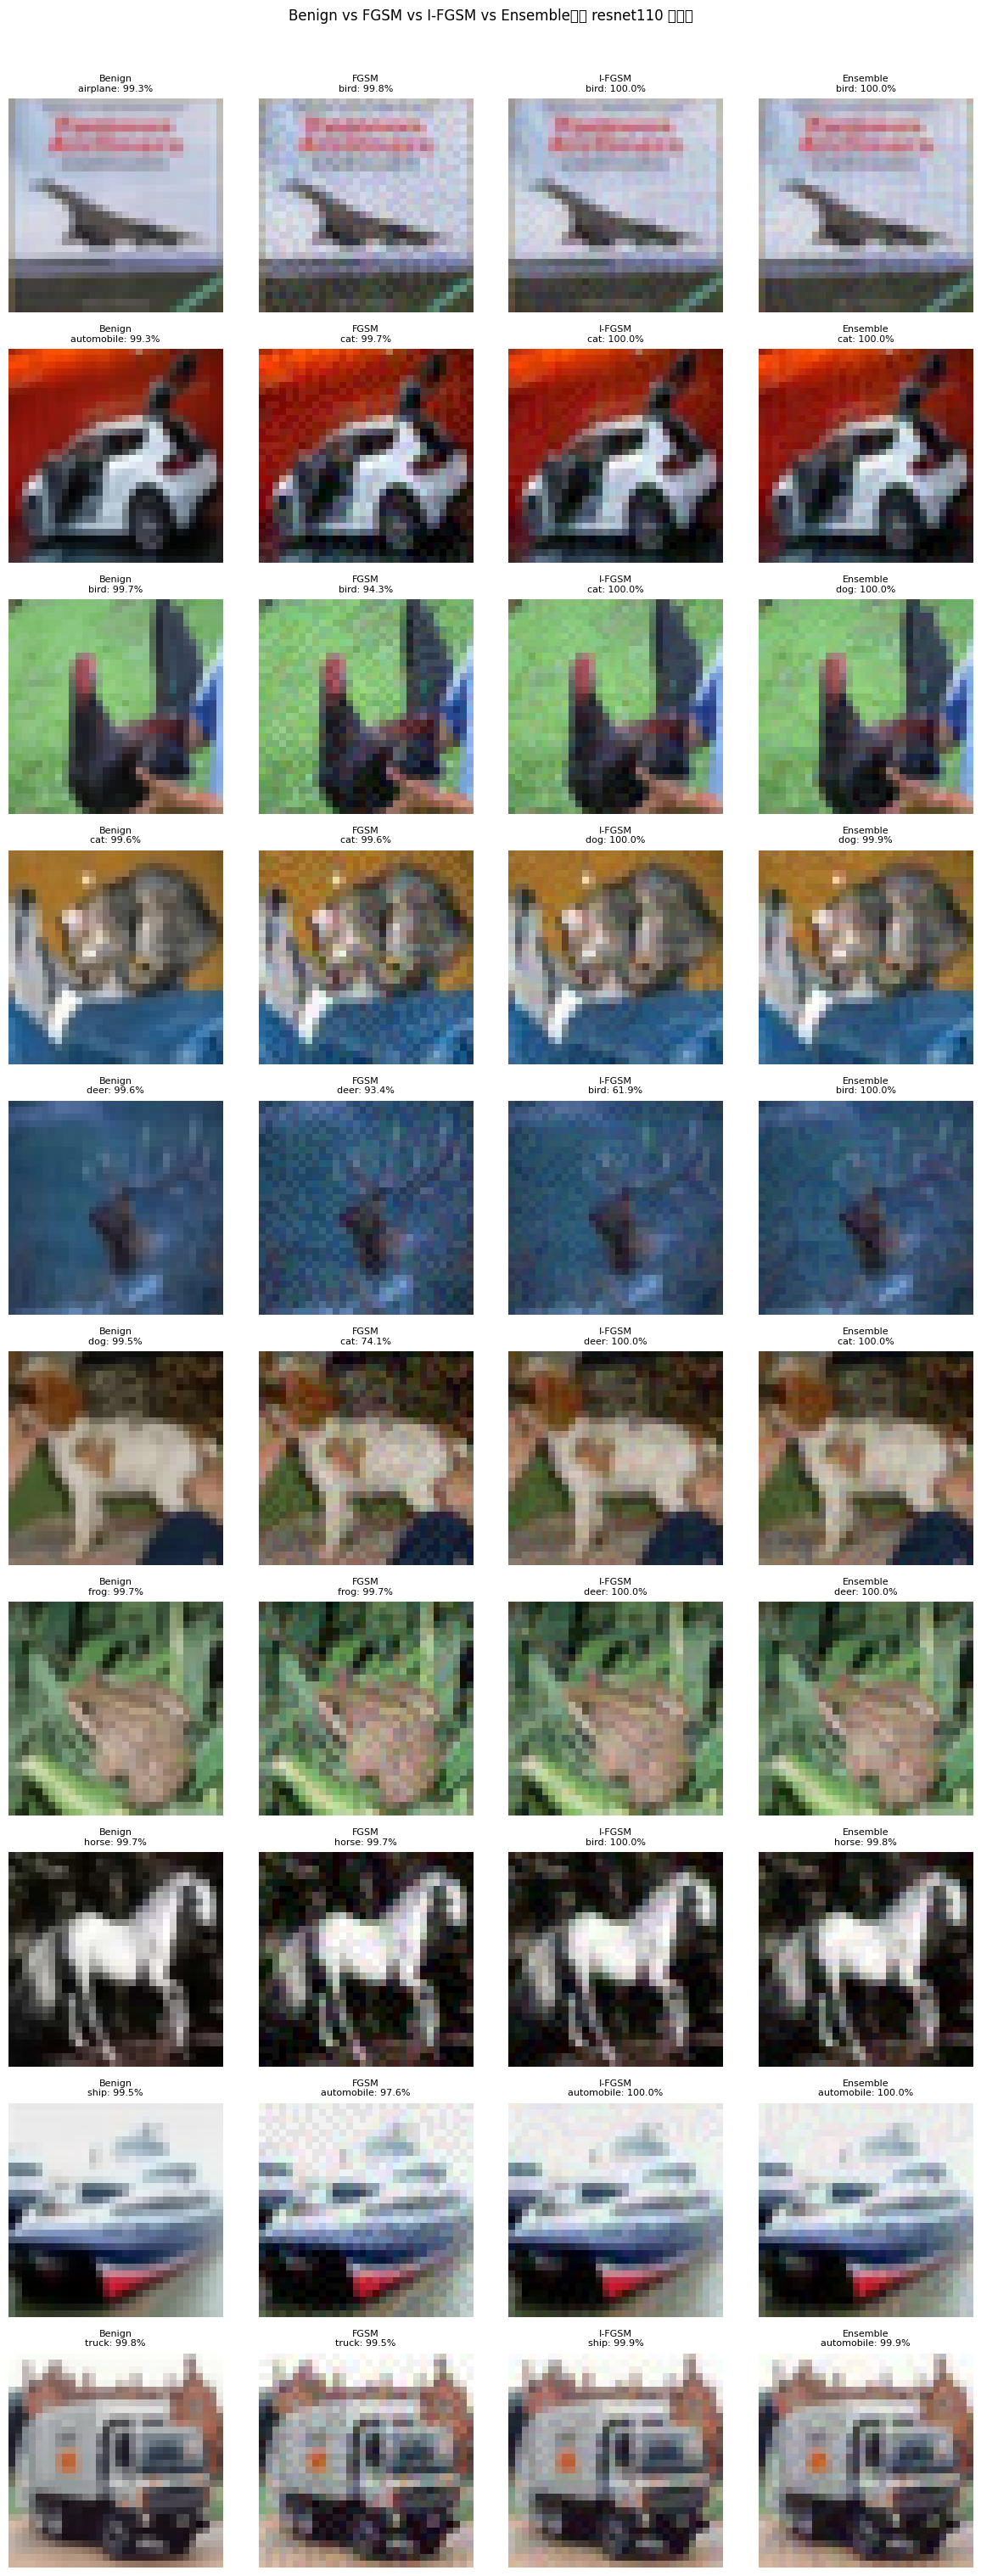

視覺化完成，已存為 comparison.png


In [16]:
import matplotlib.pyplot as plt

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# 用第一個 proxy model（resnet110）做視覺化時的預測
vis_model = proxy_models[0]
vis_model.eval()

fig, axes = plt.subplots(len(classes), 4, figsize=(12, 30))

for i, cls_name in enumerate(classes):
    path = f'{cls_name}/{cls_name}1.png'

    # --- Benign 圖片 ---
    im_benign = Image.open(f'./data/{path}')
    with torch.no_grad():
        logit = vis_model(transform(im_benign).unsqueeze(0).to(device))[0]
    pred = logit.argmax(-1).item()
    prob = logit.softmax(-1)[pred].item()
    axes[i][0].imshow(np.array(im_benign))
    axes[i][0].set_title(f'Benign\n{classes[pred]}: {prob:.1%}', fontsize=8)
    axes[i][0].axis('off')

    # --- FGSM 對抗圖片 ---
    im_fgsm = Image.open(f'./fgsm/{path}')
    with torch.no_grad():
        logit = vis_model(transform(im_fgsm).unsqueeze(0).to(device))[0]
    pred = logit.argmax(-1).item()
    prob = logit.softmax(-1)[pred].item()
    axes[i][1].imshow(np.array(im_fgsm))
    axes[i][1].set_title(f'FGSM\n{classes[pred]}: {prob:.1%}', fontsize=8)
    axes[i][1].axis('off')

    # --- I-FGSM 對抗圖片 ---
    im_ifgsm = Image.open(f'./ifgsm/{path}')
    with torch.no_grad():
        logit = vis_model(transform(im_ifgsm).unsqueeze(0).to(device))[0]
    pred = logit.argmax(-1).item()
    prob = logit.softmax(-1)[pred].item()
    axes[i][2].imshow(np.array(im_ifgsm))
    axes[i][2].set_title(f'I-FGSM\n{classes[pred]}: {prob:.1%}', fontsize=8)
    axes[i][2].axis('off')

    # --- Ensemble 對抗圖片 ---
    im_ensemble = Image.open(f'./ensemble/{path}')
    with torch.no_grad():
        logit = vis_model(transform(im_ensemble).unsqueeze(0).to(device))[0]
    pred = logit.argmax(-1).item()
    prob = logit.softmax(-1)[pred].item()
    axes[i][3].imshow(np.array(im_ensemble))
    axes[i][3].set_title(f'Ensemble\n{classes[pred]}: {prob:.1%}', fontsize=8)
    axes[i][3].axis('off')

plt.suptitle('Benign vs FGSM vs I-FGSM vs Ensemble（以 resnet110 預測）', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('視覺化完成，已存為 comparison.png')

In [17]:
# 用一個不在 proxy_models 裡的模型來評估（模擬黑箱）
# pyramidnet110_a48_cifar10 沒有被當作 proxy，適合用來評估
eval_model = ptcv_get_model('pyramidnet110_a48_cifar10', pretrained=True).to(device)
eval_model.eval()
loss_fn_eval = nn.CrossEntropyLoss()

# 建立三種攻擊結果的 DataLoader
def make_loader(adv_dir):
    dataset = AdvDataset(adv_dir, transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)

# 分別評估
benign_acc, _   = epoch_benign(eval_model, adv_loader,           loss_fn_eval)
fgsm_acc, _     = epoch_benign(eval_model, make_loader('fgsm'),     loss_fn_eval)
ifgsm_acc, _    = epoch_benign(eval_model, make_loader('ifgsm'),    loss_fn_eval)
ensemble_acc, _ = epoch_benign(eval_model, make_loader('ensemble'), loss_fn_eval)

print(f'Benign accuracy  : {benign_acc:.3f}')
print(f'FGSM accuracy    : {fgsm_acc:.3f}  (目標 ≤ 0.650)')
print(f'I-FGSM accuracy  : {ifgsm_acc:.3f}  (目標 ≤ 0.380)')
print(f'Ensemble accuracy: {ensemble_acc:.3f}  (目標 ≤ 0.180)')


Benign accuracy  : 0.960
FGSM accuracy    : 0.595  (目標 ≤ 0.650)
I-FGSM accuracy  : 0.290  (目標 ≤ 0.380)
Ensemble accuracy: 0.080  (目標 ≤ 0.180)
